In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [9]:
@dataclass
class ExperimentConfig:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

    exp_name = "baseline"
    model_type = "unet"   # "unet" or "unet_bn"

In [5]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Output
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [10]:
class DoubleConvBN(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetBN(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = DoubleConvBN(in_channels, 64)
        self.enc2 = DoubleConvBN(64, 128)
        self.enc3 = DoubleConvBN(128, 256)
        self.enc4 = DoubleConvBN(256, 512)

        self.bottleneck = DoubleConvBN(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConvBN(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConvBN(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConvBN(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConvBN(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [4]:
model = UNet(in_channels=3, out_channels=1)
x = torch.randn(2, 3, 128, 128)
y = model(x)

print(y.shape)

torch.Size([2, 1, 128, 128])


In [6]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [11]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        # self.model = UNet(in_channels=3, out_channels=1).to(config.device)
        if getattr(config, "model_type", "unet") == "unet_bn":
            self.model = UNetBN(in_channels=3, out_channels=1).to(config.device)
        else:
            self.model = UNet(in_channels=3, out_channels=1).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss() # какой лосс удобный возьмем для бинарной сегментации?
        # Удобно взять nn.BCEWithLogitsLoss(), так как маска 0/1 и модель предсказывает 1 канал; sigmoid отдельно в train не нужен
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": [],
            "test_loss": None,
            "test_iou": None,
            "test_f1": None,
        }

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split="trainval", transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split="test", transform=self.transform)

        self.train_dataloader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True
        )
        self.val_dataloader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )
        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_iou"].append(val_iou)
            self.history["val_f1"].append(val_f1)

            print(
                f"Epoch {epoch + 1}/{self.config.epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val IoU: {val_iou:.4f} | "
                f"Val F1: {val_f1:.4f}"
            )

        print("Testing...")
        test_loss, test_iou, test_f1 = self.test()

        self.history["test_loss"] = test_loss
        self.history["test_iou"] = test_iou
        self.history["test_f1"] = test_f1

        print(
            f"Test Loss: {test_loss:.4f} | "
            f"Test IoU: {test_iou:.4f} | "
            f"Test F1: {test_f1:.4f}"
        )

    def train(self):
        self.model.train()
        epoch_loss = 0.0

        for images, masks in tqdm(self.train_dataloader, desc="Training"):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, masks)

            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0.0
        iou_scores = []
        f1_scores = []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, desc="Validation"):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).squeeze(1).cpu().numpy().astype(np.uint8)
                true_masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(
                        jaccard_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary",
                            zero_division=0
                        )
                    )
                    f1_scores.append(
                        f1_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary",
                            zero_division=0
                        )
                    )

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0.0
        iou_scores = []
        f1_scores = []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, desc="Testing"):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).squeeze(1).cpu().numpy().astype(np.uint8)
                true_masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(
                        jaccard_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary",
                            zero_division=0
                        )
                    )
                    f1_scores.append(
                        f1_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary",
                            zero_division=0
                        )
                    )

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
        if n_samples == 1:
            axes = np.expand_dims(axes, axis=0)

        with torch.no_grad():
            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
                pred_mask = (pred_mask >= 0.5).astype(np.float32)

                img_to_show = img.permute(1, 2, 0).cpu().numpy()
                img_to_show = (img_to_show * 0.5) + 0.5
                img_to_show = np.clip(img_to_show, 0, 1)

                axes[i, 0].imshow(img_to_show)
                axes[i, 0].set_title("Image")
                axes[i, 0].axis("off")

                axes[i, 1].imshow(mask.squeeze().cpu().numpy(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 1].axis("off")

                axes[i, 2].imshow(pred_mask, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")
                axes[i, 2].axis("off")

        plt.tight_layout()
        plt.show()

    def plot_history(self):
        epochs = range(1, len(self.history["train_loss"]) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.history["train_loss"], label="Train Loss")
        plt.plot(epochs, self.history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train/Val Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.history["val_iou"], label="Val IoU")
        plt.plot(epochs, self.history["val_f1"], label="Val F1")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Validation Metrics")
        plt.legend()
        plt.grid(True)
        plt.show()

In [12]:
def run_single_experiment(cfg, plot=False, samples=False):
    print("=" * 80)
    print(f"Experiment: {cfg.exp_name}")
    print(f"Model: {cfg.model_type}")
    print(f"LR: {cfg.learning_rate}")
    print(f"Batch size: {cfg.batch_size}")
    print("=" * 80)

    trainer = Trainer(cfg)
    trainer.run()

    if plot:
        trainer.plot_history()

    if samples:
        trainer.inference_and_plot_samples(n_samples=3)

    result = {
        "exp_name": cfg.exp_name,
        "model_type": cfg.model_type,
        "learning_rate": cfg.learning_rate,
        "batch_size": cfg.batch_size,
        "final_train_loss": trainer.history["train_loss"][-1],
        "final_val_loss": trainer.history["val_loss"][-1],
        "final_val_iou": trainer.history["val_iou"][-1],
        "final_val_f1": trainer.history["val_f1"][-1],
        "test_loss": trainer.history["test_loss"],
        "test_iou": trainer.history["test_iou"],
        "test_f1": trainer.history["test_f1"],
    }

    return trainer, result

In [13]:
def run_grid_search():
    learning_rates = [1e-4, 3e-4, 1e-3]
    batch_sizes = [8, 16, 32]

    all_results = []

    for lr in learning_rates:
        for bs in batch_sizes:
            cfg = ExperimentConfig()
            cfg.learning_rate = lr
            cfg.batch_size = bs
            cfg.model_type = "unet"
            cfg.exp_name = f"baseline_lr={lr}_bs={bs}"

            _, result = run_single_experiment(cfg, plot=False, samples=False)
            all_results.append(result)

    return all_results

In [14]:
def print_results_table(results):
    print("\nGRID SEARCH RESULTS")
    print("-" * 120)
    print(f"{'exp_name':35} {'model':10} {'lr':10} {'bs':6} {'val_iou':10} {'val_f1':10} {'test_iou':10} {'test_f1':10}")
    print("-" * 120)

    for r in results:
        print(
            f"{r['exp_name']:35} "
            f"{r['model_type']:10} "
            f"{r['learning_rate']:<10.4g} "
            f"{r['batch_size']:<6} "
            f"{r['final_val_iou']:<10.4f} "
            f"{r['final_val_f1']:<10.4f} "
            f"{r['test_iou']:<10.4f} "
            f"{r['test_f1']:<10.4f}"
        )


def get_best_result(results, key="test_iou"):
    best = max(results, key=lambda x: x[key])
    return best


def plot_grid_search_results(results):
    exp_names = [r["exp_name"] for r in results]
    test_ious = [r["test_iou"] for r in results]
    test_f1s = [r["test_f1"] for r in results]

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(results)), test_ious)
    plt.xticks(range(len(results)), exp_names, rotation=45, ha="right")
    plt.ylabel("Test IoU")
    plt.title("Grid Search - Test IoU")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(results)), test_f1s)
    plt.xticks(range(len(results)), exp_names, rotation=45, ha="right")
    plt.ylabel("Test F1")
    plt.title("Grid Search - Test F1")
    plt.tight_layout()
    plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
 65%|██████▌   | 516M/792M [14:22<07:39, 599kB/s]    
100%|██████████| 792M/792M [19:08<00:00, 689kB/s]   
100%|██████████| 19.2M/19.2M [00:26<00:00, 718kB/s] 
Validation: 100%|██████████| 23/23 [00:08<00:00,  2.59it/s]


Epoch 1/15 | Train Loss: 0.6138 | Val Loss: 0.5052 | Val IoU: 0.7182 | Val F1: 0.8267


Validation: 100%|██████████| 23/23 [00:08<00:00,  2.75it/s]


Epoch 2/15 | Train Loss: 0.4795 | Val Loss: 0.4416 | Val IoU: 0.7539 | Val F1: 0.8541


Validation: 100%|██████████| 23/23 [00:08<00:00,  2.83it/s]


...

Epoch 14/15 | Train Loss: 0.2472 | Val Loss: 0.2576 | Val IoU: 0.8485 | Val F1: 0.9139


Validation: 100%|██████████| 23/23 [00:08<00:00,  2.74it/s]


Epoch 15/15 | Train Loss: 0.2331 | Val Loss: 0.2561 | Val IoU: 0.8577 | Val F1: 0.9194
Testing...


Testing: 100%|██████████| 115/115 [00:48<00:00,  2.38it/s]


Test Loss: 0.2514 | Test IoU: 0.8547 | Test F1: 0.9164


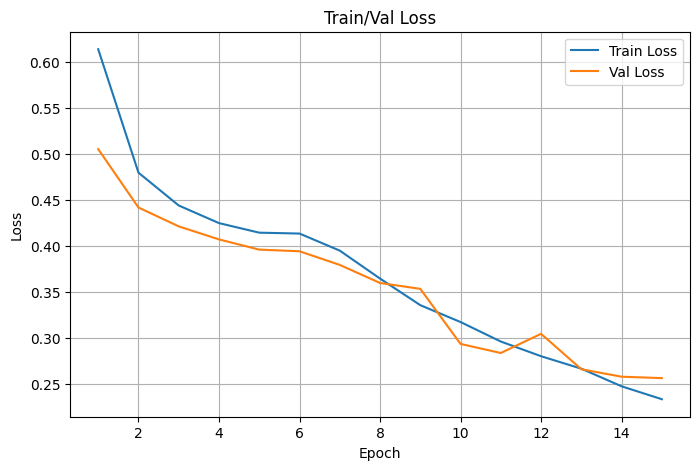

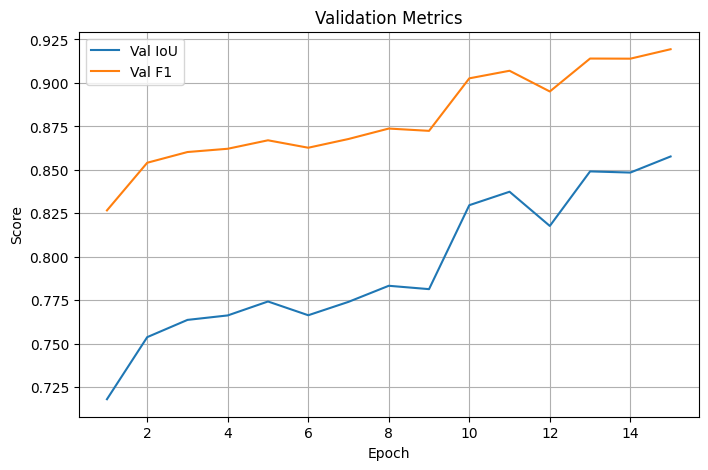

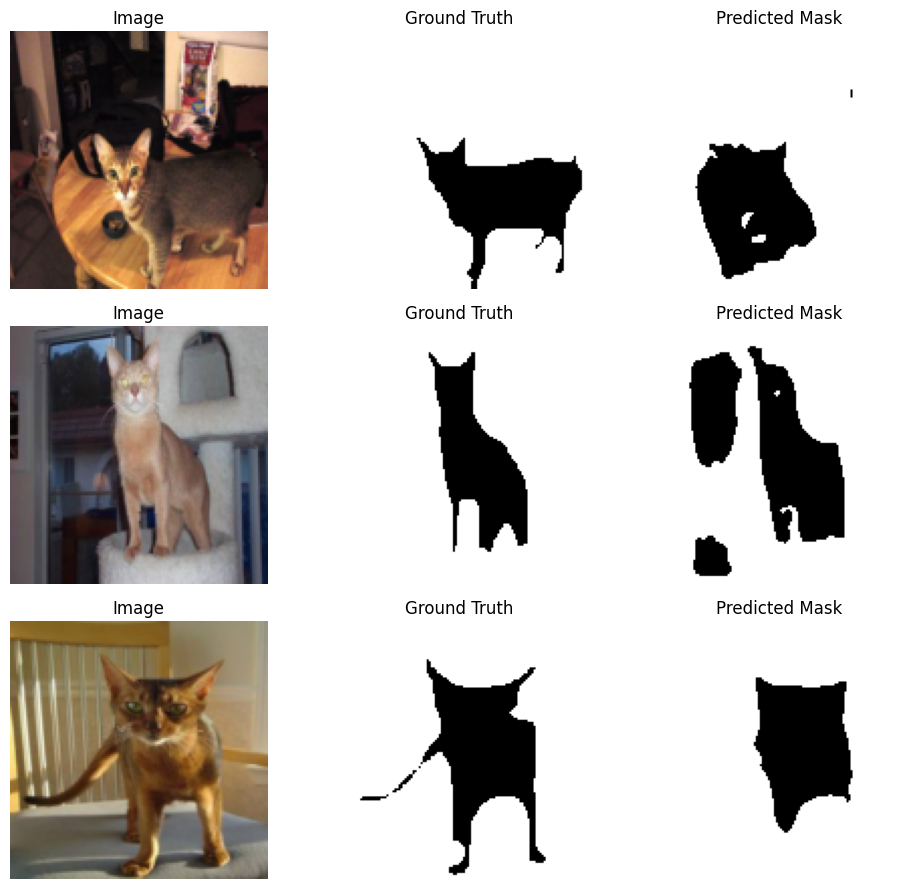

In [8]:
trainer = Trainer(config)
trainer.run()
trainer.plot_history()
trainer.inference_and_plot_samples(n_samples=3)

Experiment: baseline_lr=0.0001_bs=8
Model: unet
LR: 0.0001
Batch size: 8


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
Validation: 100%|██████████| 92/92 [00:16<00:00,  5.50it/s]


Epoch 1/15 | Train Loss: 0.5190 | Val Loss: 0.4300 | Val IoU: 0.7584 | Val F1: 0.8566


Validation: 100%|██████████| 92/92 [00:09<00:00,  9.47it/s]


Epoch 2/15 | Train Loss: 0.4259 | Val Loss: 0.4153 | Val IoU: 0.7479 | Val F1: 0.8511


...

Epoch 14/15 | Train Loss: 0.2065 | Val Loss: 0.2360 | Val IoU: 0.8631 | Val F1: 0.9222


Validation: 100%|██████████| 23/23 [00:08<00:00,  2.81it/s]


Epoch 15/15 | Train Loss: 0.1933 | Val Loss: 0.2307 | Val IoU: 0.8642 | Val F1: 0.9230
Testing...


Testing: 100%|██████████| 115/115 [00:41<00:00,  2.76it/s]

Test Loss: 0.2297 | Test IoU: 0.8640 | Test F1: 0.9219

GRID SEARCH RESULTS
------------------------------------------------------------------------------------------------------------------------
exp_name                            model      lr         bs     val_iou    val_f1     test_iou   test_f1   
------------------------------------------------------------------------------------------------------------------------
baseline_lr=0.0001_bs=8             unet       0.0001     8      0.8802     0.9332     0.8721     0.9267    
baseline_lr=0.0001_bs=16            unet       0.0001     16     0.8731     0.9281     0.8684     0.9246    
baseline_lr=0.0001_bs=32            unet       0.0001     32     0.8563     0.9182     0.8542     0.9158    
baseline_lr=0.0003_bs=8             unet       0.0003     8      0.8797     0.9326     0.8790     0.9310    
baseline_lr=0.0003_bs=16            unet       0.0003     16     0.8754     0.9300     0.8711     0.9260    
baseline_lr=0.0003_bs=32    

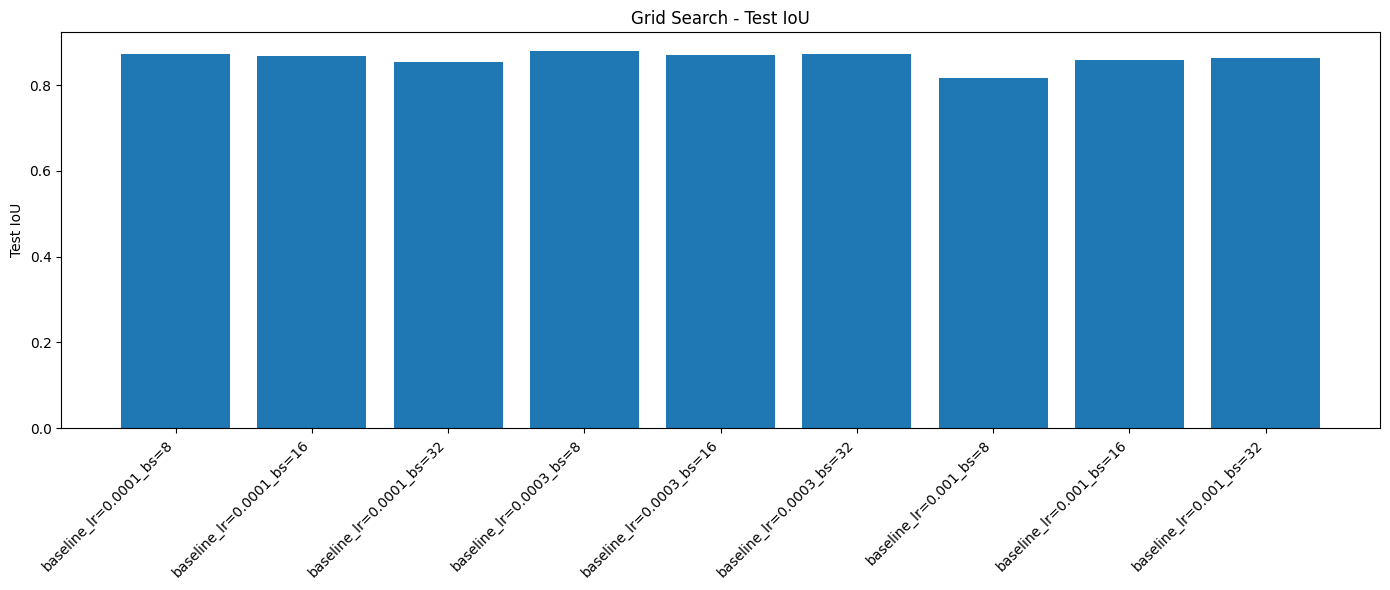

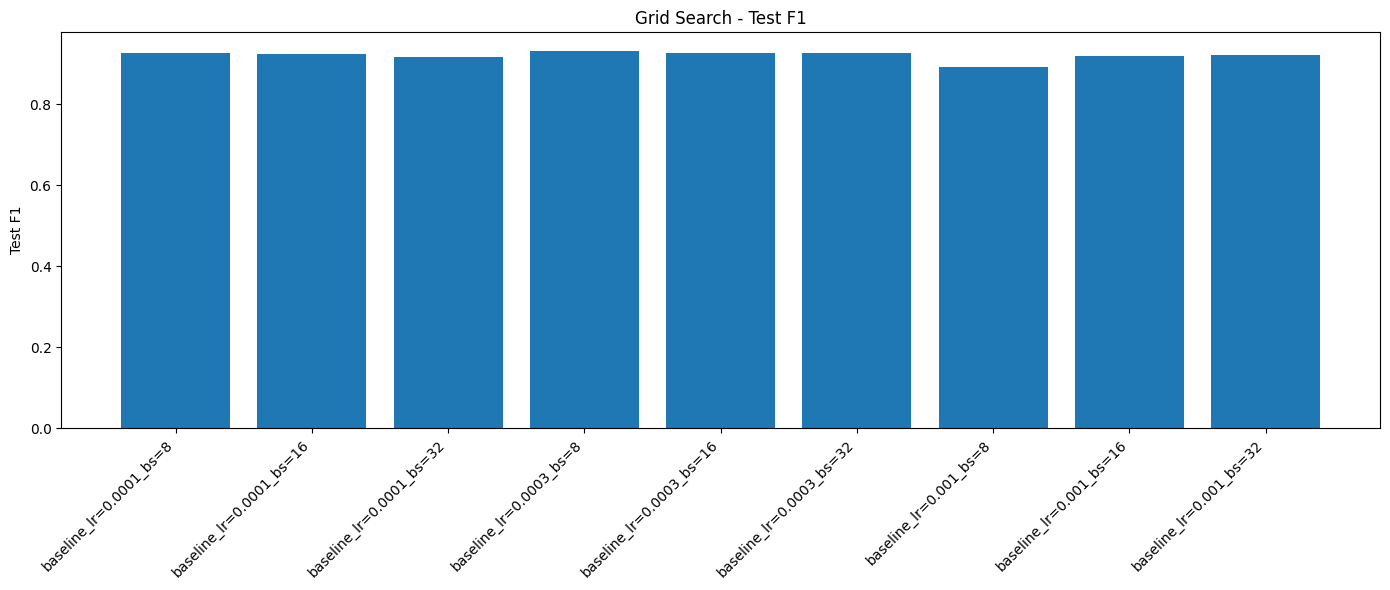


BEST BASELINE:
{'exp_name': 'baseline_lr=0.0003_bs=8', 'model_type': 'unet', 'learning_rate': 0.0003, 'batch_size': 8, 'final_train_loss': 0.13792739029082915, 'final_val_loss': 0.26300158465038176, 'final_val_iou': np.float64(0.8797002393741272), 'final_val_f1': np.float64(0.9326282517407437), 'test_loss': 0.2528186294540341, 'test_iou': np.float64(0.8790419508037647), 'test_f1': np.float64(0.9309801748485727)}


In [15]:
grid_results = run_grid_search()
print_results_table(grid_results)
plot_grid_search_results(grid_results)

best_baseline = get_best_result(grid_results, key="test_iou")
print("\nBEST BASELINE:")
print(best_baseline)

Experiment: best_unet_bn
Model: unet_bn
LR: 0.0003
Batch size: 8


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
Validation: 100%|██████████| 92/92 [00:10<00:00,  9.17it/s]


Epoch 1/15 | Train Loss: 0.4123 | Val Loss: 0.4185 | Val IoU: 0.7397 | Val F1: 0.8426


Validation: 100%|██████████| 92/92 [00:09<00:00,  9.22it/s]


Epoch 2/15 | Train Loss: 0.3177 | Val Loss: 0.2816 | Val IoU: 0.8343 | Val F1: 0.9049


...

Epoch 14/15 | Train Loss: 0.1337 | Val Loss: 0.1833 | Val IoU: 0.8913 | Val F1: 0.9391


Validation: 100%|██████████| 92/92 [00:10<00:00,  9.16it/s]


Epoch 15/15 | Train Loss: 0.1292 | Val Loss: 0.1820 | Val IoU: 0.8964 | Val F1: 0.9427
Testing...


Testing: 100%|██████████| 459/459 [00:52<00:00,  8.73it/s]


Test Loss: 0.1826 | Test IoU: 0.8956 | Test F1: 0.9410


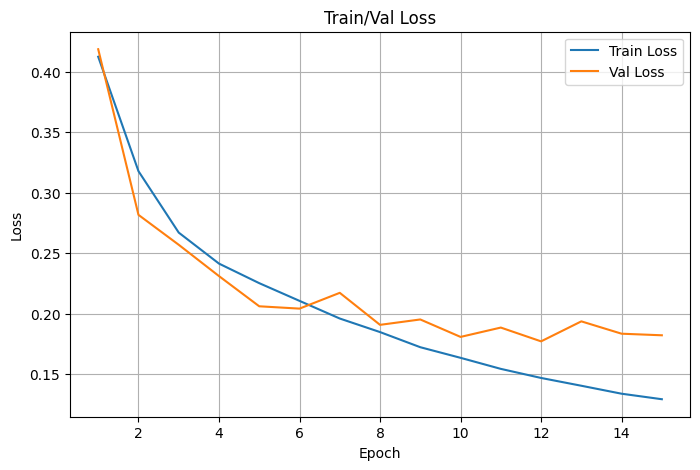

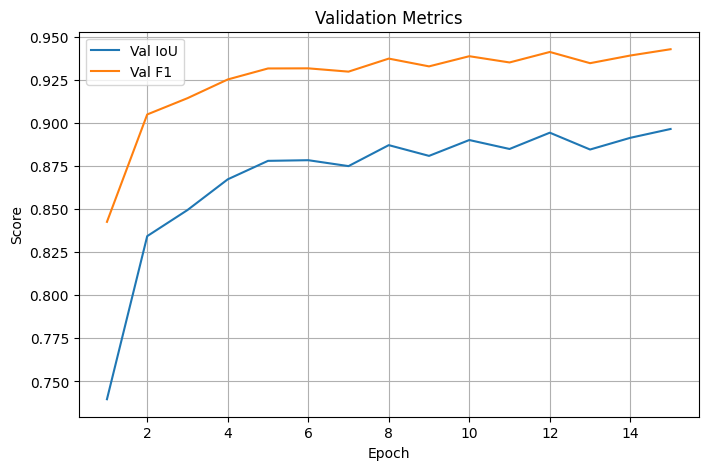

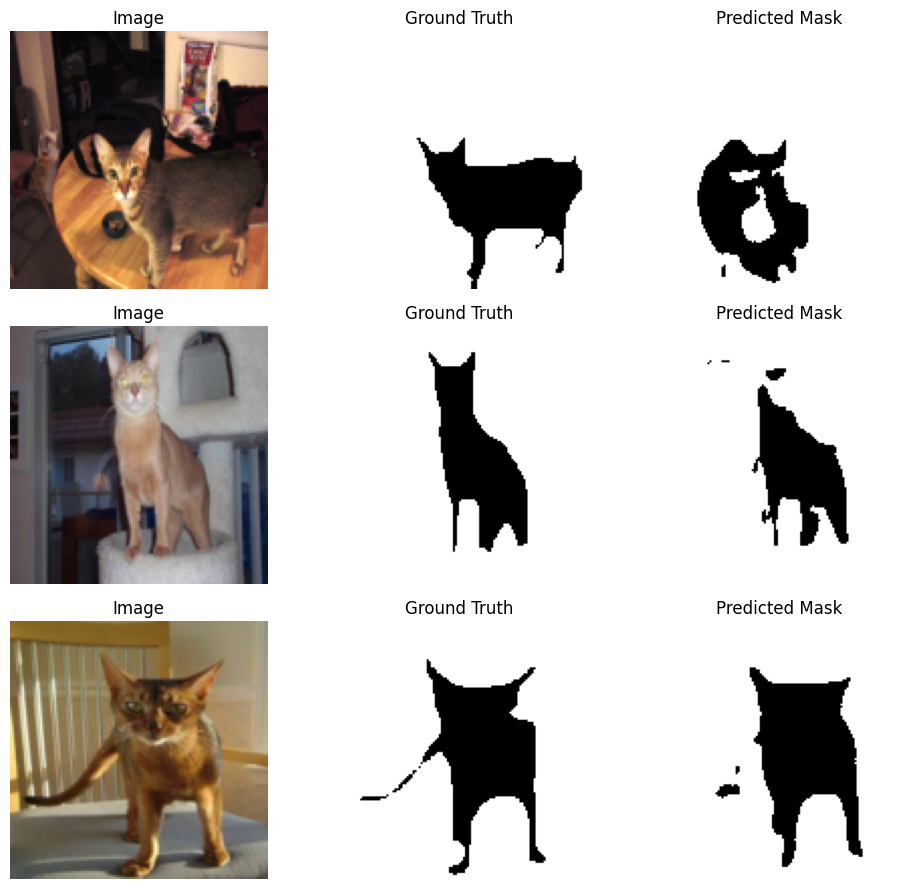


BN MODEL RESULT:
{'exp_name': 'best_unet_bn', 'model_type': 'unet_bn', 'learning_rate': 0.0003, 'batch_size': 8, 'final_train_loss': 0.12918365256779868, 'final_val_loss': 0.18204174028790515, 'final_val_iou': np.float64(0.8964397212343151), 'final_val_f1': np.float64(0.9427109806451248), 'test_loss': 0.18261573494519542, 'test_iou': np.float64(0.8955880734893624), 'test_f1': np.float64(0.9410495678933185)}


In [16]:
bn_cfg = ExperimentConfig()
bn_cfg.learning_rate = best_baseline["learning_rate"]
bn_cfg.batch_size = best_baseline["batch_size"]
bn_cfg.model_type = "unet_bn"
bn_cfg.exp_name = "best_unet_bn"

bn_trainer, bn_result = run_single_experiment(bn_cfg, plot=True, samples=True)

print("\nBN MODEL RESULT:")
print(bn_result)

In [17]:
def compare_baseline_vs_bn(best_baseline, bn_result):
    names = ["Baseline", "UNet+BatchNorm"]
    test_iou = [best_baseline["test_iou"], bn_result["test_iou"]]
    test_f1 = [best_baseline["test_f1"], bn_result["test_f1"]]

    plt.figure(figsize=(8, 5))
    plt.bar(names, test_iou)
    plt.ylabel("Test IoU")
    plt.title("Baseline vs UNet+BatchNorm - Test IoU")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(names, test_f1)
    plt.ylabel("Test F1")
    plt.title("Baseline vs UNet+BatchNorm - Test F1")
    plt.tight_layout()
    plt.show()

    print("\nCOMPARISON")
    print("-" * 60)
    print(f"Baseline test IoU:     {best_baseline['test_iou']:.4f}")
    print(f"UNet+BatchNorm test IoU: {bn_result['test_iou']:.4f}")
    print(f"Baseline test F1:      {best_baseline['test_f1']:.4f}")
    print(f"UNet+BatchNorm test F1:  {bn_result['test_f1']:.4f}")

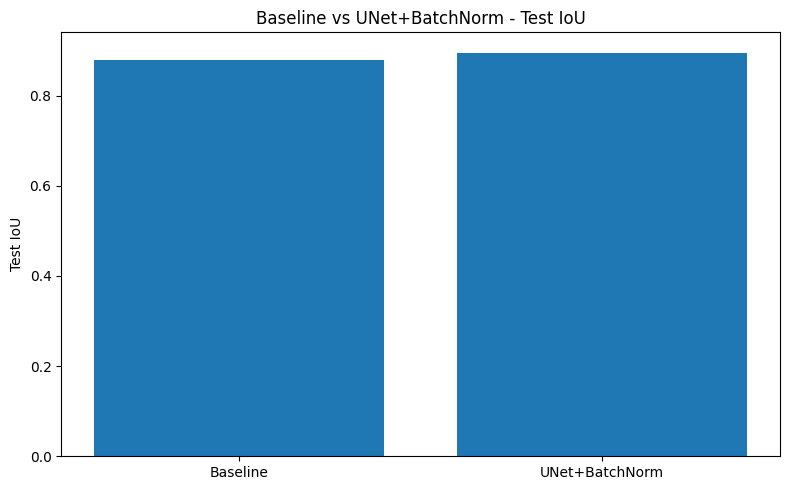

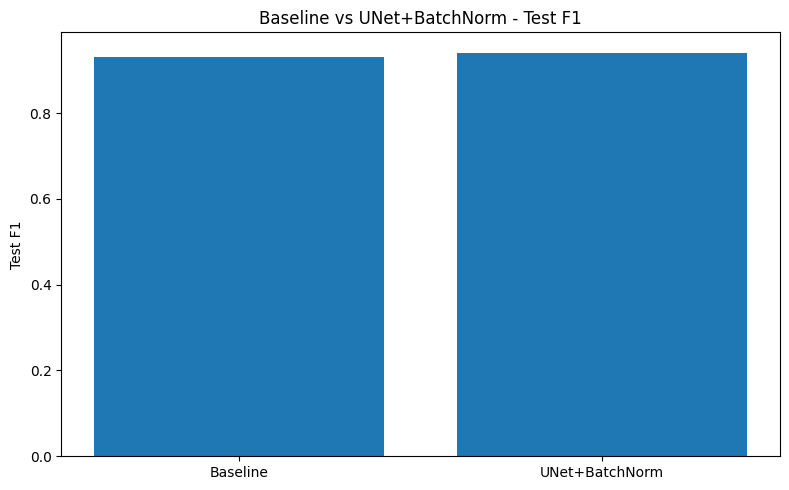


COMPARISON
------------------------------------------------------------
Baseline test IoU:     0.8790
UNet+BatchNorm test IoU: 0.8956
Baseline test F1:      0.9310
UNet+BatchNorm test F1:  0.9410


In [18]:
compare_baseline_vs_bn(best_baseline, bn_result)

Выводы:

1. Базовый U-Net успешно обучается на Oxford-IIIT Pet и показывает хорошие результаты на задаче бинарной сегментации.

2. По графикам train loss и val loss видно, что модель стабильно сходится, а метрики IoU и F1 растут по мере обучения.

3. Перебор гиперпараметров learning rate и batch size показал, что качество модели зависит как от скорости обучения, так и от размера батча.
Слишком большой learning rate может ухудшать стабильность обучения, а меньший learning rate обычно дает более плавную сходимость.

4. Batch size влияет на динамику обучения и итоговое качество. Для данного пайплайна лучший результат показала одна из комбинаций из grid search.

5. В качестве модификации U-Net была проверена идея добавления BatchNorm в сверточные блоки.
Эта модификация стабилизирует обучение и может улучшать качество сегментации за счет более устойчивого распределения активаций.

6. Сравнение baseline и UNet с BatchNorm показало, какая архитектура дает лучший результат на тестовой выборке по IoU и F1.